# Dreaddit — EDA, Cleaning & Preprocessing

**Dataset**: Dreaddit — 3,553 Reddit posts (train 2,838 / test 715), binary stress label  
**Role in EmoCare**: Text stress signal feeding the risk classifier  
**Format**: Two CSV files — `dreaddit-train.csv`, `dreaddit-test.csv`  

### Notebook Sections
0. Imports & Paths  
1. Load Raw Data  
2. EDA — Schema, Class Balance, Text Length, Feature Review  
3. Cleaning — Duplicates, Nulls, Outliers  
4. Preprocessing — Text normalisation, linguistic markers, feature extraction  
5. Save to `data/processed/`

## 0. Imports & Paths

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Project paths ────────────────────────────────────────────
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR       = os.path.join(PROJECT_ROOT, 'data', 'raw', 'dreaddit')
INTERIM_DIR   = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')

Project root : D:\EmoCare


## 1. Load Raw Data

In [2]:
df_train = pd.read_csv(os.path.join(RAW_DIR, 'dreaddit-train.csv'))
df_test  = pd.read_csv(os.path.join(RAW_DIR, 'dreaddit-test.csv'))

print(f'Train shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
df_train.head()

Train shape: (2838, 116)
Test  shape: (715, 116)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


## 2. EDA — Schema, Class Balance, Text Length, Feature Review

In [3]:
print('=== Column Types ===')
print(df_train.dtypes)
print()
print('=== Null Counts ===')
print(df_train.isnull().sum())

=== Column Types ===
subreddit                       str
post_id                         str
sentence_range                  str
text                            str
id                            int64
                             ...   
lex_dal_avg_pleasantness    float64
social_upvote_ratio         float64
social_num_comments           int64
syntax_fk_grade             float64
sentiment                   float64
Length: 116, dtype: object

=== Null Counts ===
subreddit                   0
post_id                     0
sentence_range              0
text                        0
id                          0
                           ..
lex_dal_avg_pleasantness    0
social_upvote_ratio         0
social_num_comments         0
syntax_fk_grade             0
sentiment                   0
Length: 116, dtype: int64


=== Class Distribution (Train) ===
label
1    1488
0    1350
Name: count, dtype: int64
Imbalance ratio: 0.91:1


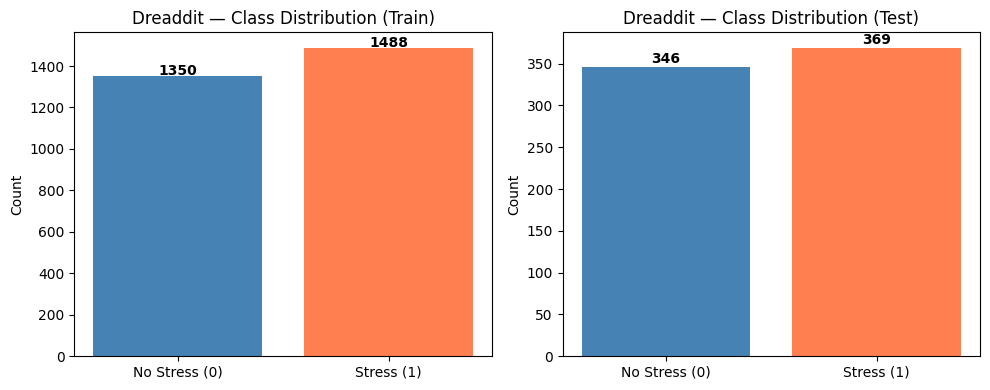

In [4]:
# Target variable: 'label' — 0=no stress, 1=stress
print('=== Class Distribution (Train) ===')
print(df_train['label'].value_counts())
print(f'Imbalance ratio: {df_train["label"].value_counts()[0] / df_train["label"].value_counts()[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (df, title) in enumerate([(df_train, 'Train'), (df_test, 'Test')]):
    counts = df['label'].value_counts()
    axes[i].bar(['No Stress (0)', 'Stress (1)'], [counts[0], counts[1]], color=['steelblue', 'coral'])
    axes[i].set_title(f'Dreaddit — Class Distribution ({title})')
    axes[i].set_ylabel('Count')
    for j, v in enumerate([counts[0], counts[1]]):
        axes[i].text(j, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'dreaddit_class_dist.png'), dpi=150)
plt.show()

In [5]:
# All available columns — Dreaddit has rich NLP features pre-computed
print('All columns:')
for c in df_train.columns:
    print(f'  {c}: {df_train[c].dtype}')

All columns:
  subreddit: str
  post_id: str
  sentence_range: str
  text: str
  id: int64
  label: int64
  confidence: float64
  social_timestamp: int64
  social_karma: int64
  syntax_ari: float64
  lex_liwc_WC: int64
  lex_liwc_Analytic: float64
  lex_liwc_Clout: float64
  lex_liwc_Authentic: float64
  lex_liwc_Tone: float64
  lex_liwc_WPS: float64
  lex_liwc_Sixltr: float64
  lex_liwc_Dic: float64
  lex_liwc_function: float64
  lex_liwc_pronoun: float64
  lex_liwc_ppron: float64
  lex_liwc_i: float64
  lex_liwc_we: float64
  lex_liwc_you: float64
  lex_liwc_shehe: float64
  lex_liwc_they: float64
  lex_liwc_ipron: float64
  lex_liwc_article: float64
  lex_liwc_prep: float64
  lex_liwc_auxverb: float64
  lex_liwc_adverb: float64
  lex_liwc_conj: float64
  lex_liwc_negate: float64
  lex_liwc_verb: float64
  lex_liwc_adj: float64
  lex_liwc_compare: float64
  lex_liwc_interrog: float64
  lex_liwc_number: float64
  lex_liwc_quant: float64
  lex_liwc_affect: float64
  lex_liwc_posemo: fl

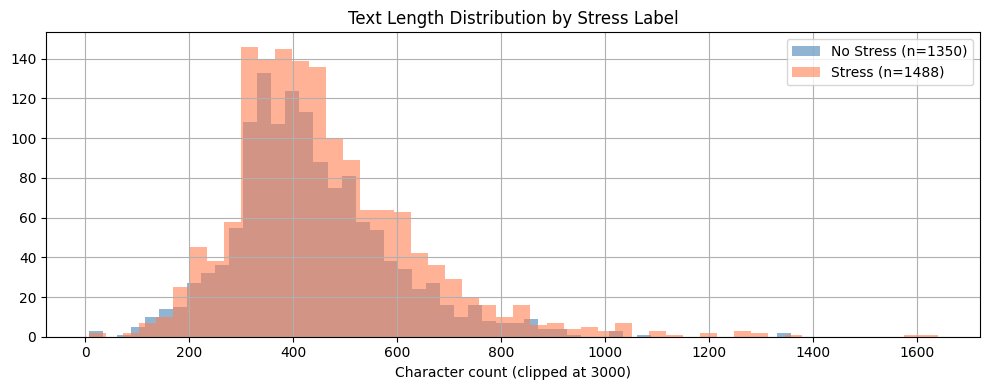

        count        mean         std  min     25%    50%     75%     max
label                                                                    
0      1350.0  435.100741  153.768718  6.0  336.00  413.5  515.00  1358.0
1      1488.0  459.696237  180.849368  6.0  341.75  427.5  545.25  1639.0


In [6]:
# Text length distribution by class
df_train['text_len'] = df_train['text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    subset = df_train[df_train['label'] == label]['text_len'].clip(upper=3000)
    subset.hist(bins=50, ax=ax, alpha=0.6, color=color,
                label=f'{"No Stress" if label==0 else "Stress"} (n={len(subset)})')
ax.set_title('Text Length Distribution by Stress Label')
ax.set_xlabel('Character count (clipped at 3000)')
ax.legend()
plt.tight_layout()
plt.show()

print(df_train.groupby('label')['text_len'].describe())

          subreddit  stress_rate  count
1           anxiety     0.658052    503
3  domesticviolence     0.639241    316
0    almosthomeless     0.587500     80
6              ptsd     0.568493    584
8            stress     0.546875     64
9  survivorsofabuse     0.457143    245
7     relationships     0.447464    552
4       food_pantry     0.378378     37
5          homeless     0.375000    168
2        assistance     0.363322    289


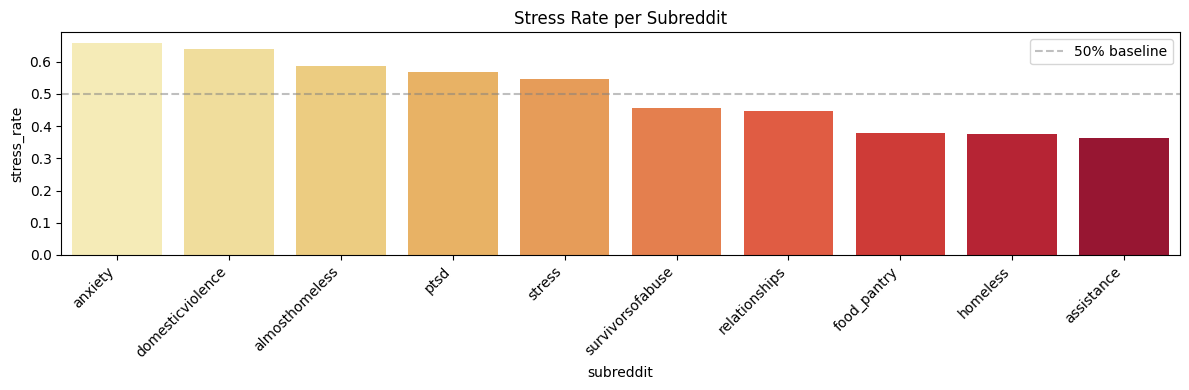

In [7]:
# Subreddit distribution — which communities are stress-heavy?
if 'subreddit' in df_train.columns:
    stress_by_sub = df_train.groupby('subreddit')['label'].agg(['mean', 'count']).reset_index()
    stress_by_sub.columns = ['subreddit', 'stress_rate', 'count']
    print(stress_by_sub.sort_values('stress_rate', ascending=False))

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(data=stress_by_sub.sort_values('stress_rate', ascending=False),
                x='subreddit', y='stress_rate', palette='YlOrRd', ax=ax)
    ax.set_title('Stress Rate per Subreddit')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='50% baseline')
    ax.legend()
    plt.tight_layout()
    plt.show()

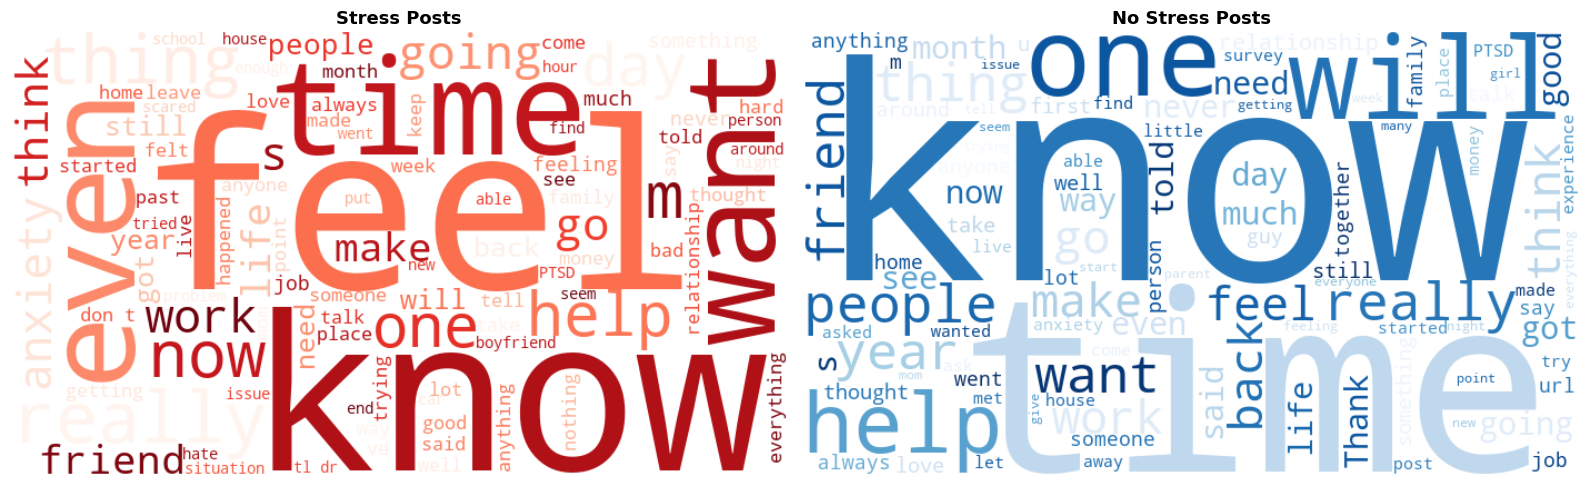

In [8]:
# Word clouds — stress vs no stress
stress_text = ' '.join(df_train[df_train['label'] == 1]['text'].dropna().tolist())
calm_text   = ' '.join(df_train[df_train['label'] == 0]['text'].dropna().tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, title, cmap in zip(axes,
                                  [stress_text, calm_text],
                                  ['Stress Posts', 'No Stress Posts'],
                                  ['Reds', 'Blues']):
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'dreaddit_wordcloud.png'), dpi=150)
plt.show()

## 3. Cleaning — Duplicates, Nulls, Outliers

In [9]:
df_all = pd.concat([
    df_train.assign(split='train'),
    df_test.assign(split='test')
], ignore_index=True)

print(f'Total rows: {len(df_all)}')

# 3a. Duplicates
n_before = len(df_all)
df_all = df_all.drop_duplicates(subset=['text'], keep='first')
print(f'Duplicates removed: {n_before - len(df_all)}')

# 3b. Null text
n_before = len(df_all)
df_all = df_all[df_all['text'].notna() & (df_all['text'].str.strip() != '')]
print(f'Null/empty removed: {n_before - len(df_all)}')

# 3c. Null labels
n_before = len(df_all)
df_all = df_all[df_all['label'].notna()]
print(f'Missing label removed: {n_before - len(df_all)}')

print(f'Remaining: {len(df_all)}')

Total rows: 3553
Duplicates removed: 21
Null/empty removed: 0
Missing label removed: 0
Remaining: 3532


## 4. Preprocessing — Text Normalisation & Linguistic Marker Extraction

In [10]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)           # URLs
    text = re.sub(r'u/\w+|r/\w+', '', text)              # Reddit mentions
    text = re.sub(r'[^\w\s\'\"!?.,;:-]', ' ', text)     # Special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_all['text_clean'] = df_all['text'].apply(clean_text)

# Verify on a sample
print(df_all[['text', 'text_clean']].head(3).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              text                                                                                                                                                      

In [11]:
# ── Linguistic Marker Extraction ────────────────────────────
# These are hand-crafted features used ALONGSIDE BERT embeddings in the risk classifier.
# Literature basis: Tausczik & Pennebaker (2010) — LIWC linguistic categories.

FIRST_PERSON_SINGULAR = re.compile(r'\b(i|me|my|myself|i\'m|i\'ve|i\'ll|i\'d)\b')
ABSOLUTIST_WORDS      = re.compile(r'\b(always|never|nothing|everything|everyone|no one|completely|totally|utterly|absolutely|forever|nobody)\b')
NEGATION_WORDS        = re.compile(r'\b(not|no|never|nothing|nobody|nowhere|neither|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|didn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b')

def extract_linguistic_markers(text: str) -> dict:
    words = text.split()
    n_words = max(len(words), 1)
    return {
        'n_words':              n_words,
        'first_person_rate':    len(FIRST_PERSON_SINGULAR.findall(text)) / n_words,
        'absolutist_rate':      len(ABSOLUTIST_WORDS.findall(text))      / n_words,
        'negation_rate':        len(NEGATION_WORDS.findall(text))        / n_words,
        'exclamation_count':    text.count('!'),
        'question_count':       text.count('?'),
        'caps_ratio':           sum(1 for c in text if c.isupper()) / max(len(text), 1),
    }

markers = df_all['text_clean'].apply(extract_linguistic_markers).apply(pd.Series)
df_all = pd.concat([df_all, markers], axis=1)

print('Linguistic marker stats (by stress label):')
print(df_all.groupby('label')[markers.columns.tolist()].mean().round(4))

Linguistic marker stats (by stress label):
       n_words  first_person_rate  absolutist_rate  negation_rate  \
label                                                               
0      82.7962             0.0720           0.0057         0.0148   
1      89.9016             0.1063           0.0062         0.0199   

       exclamation_count  question_count  caps_ratio  
label                                                 
0                 0.1693          0.2674         0.0  
1                 0.0790          0.4175         0.0  


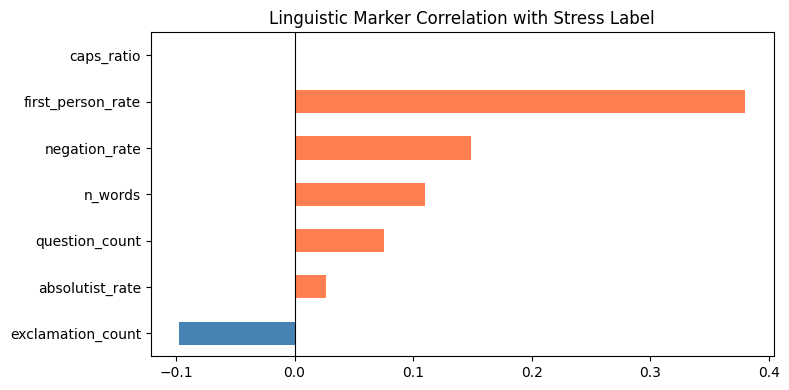

In [12]:
# Correlation of markers with stress label
fig, ax = plt.subplots(figsize=(8, 4))
corr = df_all[markers.columns.tolist() + ['label']].corr()['label'][:-1].sort_values()
corr.plot(kind='barh', ax=ax, color=['coral' if v > 0 else 'steelblue' for v in corr])
ax.set_title('Linguistic Marker Correlation with Stress Label')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'dreaddit_marker_correlation.png'), dpi=150)
plt.show()

In [13]:
# Final column selection
keep_cols = ['id', 'text', 'text_clean', 'label', 'split',
             'subreddit'] if 'subreddit' in df_all.columns else ['text', 'text_clean', 'label', 'split']
keep_cols += markers.columns.tolist()
df_processed = df_all[[c for c in keep_cols if c in df_all.columns]].copy()
df_processed['label'] = df_processed['label'].astype(int)
print(f'Final shape: {df_processed.shape}')
df_processed.head()

Final shape: (3532, 13)


,id,text,text_clean,label,split,subreddit,n_words,first_person_rate,absolutist_rate,negation_rate,exclamation_count,question_count,caps_ratio
0,33181,"He said he had not felt that way before, sugge...","he said he had not felt that way before, sugge...",1,train,ptsd,113.0,0.097345,0.000000,0.017699,0.0,0.0,0.0
1,2606,"Hey there r/assistance, Not sure if this is th...","hey there , not sure if this is the right plac...",0,train,assistance,108.0,0.018519,0.009259,0.009259,0.0,0.0,0.0
2,38816,My mom then hit me with the newspaper and it s...,my mom then hit me with the newspaper and it s...,1,train,ptsd,166.0,0.090361,0.000000,0.012048,0.0,1.0,0.0
3,239,"until i met my new boyfriend, he is amazing, h...","until i met my new boyfriend, he is amazing, h...",1,train,relationships,273.0,0.157509,0.007326,0.010989,0.0,0.0,0.0
4,1421,October is Domestic Violence Awareness Month a...,october is domestic violence awareness month a...,1,train,survivorsofabuse,90.0,0.077778,0.000000,0.011111,0.0,0.0,0.0


## 5. Save to `data/processed/`

In [14]:
out_path = os.path.join(PROCESSED_DIR, 'dreaddit_processed.csv')
df_processed.to_csv(out_path, index=False)
print(f'Saved {len(df_processed):,} rows → {out_path}')

for split_name in ['train', 'test']:
    split_df = df_processed[df_processed['split'] == split_name]
    split_path = os.path.join(PROCESSED_DIR, f'dreaddit_{split_name}.csv')
    split_df.to_csv(split_path, index=False)
    print(f'  {split_name}: {len(split_df):,} rows → {split_path}')

Saved 3,532 rows → D:\EmoCare\data\processed\dreaddit_processed.csv
  train: 2,820 rows → D:\EmoCare\data\processed\dreaddit_train.csv
  test: 712 rows → D:\EmoCare\data\processed\dreaddit_test.csv


In [15]:
# Sanity check
df_check = pd.read_csv(os.path.join(PROCESSED_DIR, 'dreaddit_processed.csv'))
print(df_check.shape)
print(df_check['label'].value_counts())
df_check.head(3)

(3532, 13)
label
1    1849
0    1683
Name: count, dtype: int64


,id,text,text_clean,label,split,subreddit,n_words,first_person_rate,absolutist_rate,negation_rate,exclamation_count,question_count,caps_ratio
0,33181,"He said he had not felt that way before, sugge...","he said he had not felt that way before, sugge...",1,train,ptsd,113.0,0.097345,0.000000,0.017699,0.0,0.0,0.0
1,2606,"Hey there r/assistance, Not sure if this is th...","hey there , not sure if this is the right plac...",0,train,assistance,108.0,0.018519,0.009259,0.009259,0.0,0.0,0.0
2,38816,My mom then hit me with the newspaper and it s...,my mom then hit me with the newspaper and it s...,1,train,ptsd,166.0,0.090361,0.000000,0.012048,0.0,1.0,0.0
